# Is CPI morning really the market's biggest day? 📊🌡️
### The Fed's favorite number, put through the desk's honesty rails

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Biggest_day%3F: Busted](https://img.shields.io/badge/Biggest_day%3F-Busted-8b949e?style=flat-square)

Twelve times a year, before the opening bell, the Bureau of Labor Statistics drops the inflation report. Since the Fed started hiking rates in 2022, trading desks call it the biggest print of the month — bigger than earnings, bigger than jobs day, bigger than anything the Fed itself says. *This* number decides whether the Fed hikes, holds, or cuts.

So does the market actually **move** on CPI morning — and does it move in a direction you could bank? We tested it on 353 real CPI releases since 1997, on both stocks (SPY) and the long bond (TLT).

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 353 actual CPI release dates (1997→2026) hardcoded from the BLS's own archive — not a weekday-pattern guess. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cpi_day_drift import data, strategy as st

CPI = data.cpi_calendar()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY_PX, TLT_PX = data.load_real()
    SPY_SESSIONS, _ = data.map_to_sessions(SPY_PX.index, CPI)
    TLT_SESSIONS, _ = data.map_to_sessions(TLT_PX.index, CPI)
    SPY = st.day_frame(SPY_PX, SPY_SESSIONS)
    TLT = st.day_frame(TLT_PX, TLT_SESSIONS)
else:
    SPY_PX = TLT_PX = SPY = TLT = None
    SPY_SESSIONS = TLT_SESSIONS = None
print("real cache present:", HAVE_REAL, "| CPI releases:", len(CPI),
      "| SPY tape days:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1997-01-02', 'end': '2026-06-30', 'n_cpi': 353, 'n_spy_rest': 7065, 'n_tlt_rest': 5731, 'n_tlt_events': 286, 'cal_lo': '1997-01-14', 'cal_hi': '2026-06-10', 'spy_cpi_bps': 3.73, 'spy_rest_bps': 3.8, 'spy_gap_bps': -0.07, 'spy_welch': -0.01, 'spy_nw': -0.01, 'spy_hit': 198, 'spy_hit_pct': 56.1, 'spy_wilson': (50.9, 61.2), 'tlt_cpi_bps': 5.24, 'tlt_rest_bps': 1.26, 'tlt_gap_bps': 3.98, 'tlt_welch': 0.67, 'tlt_nw': 0.67, 'tlt_hit': 156, 'tlt_hit_pct': 54.5, 'tlt_wilson': (48.8, 60.2), 'plac_spy_ret_obs': 3.73, 'plac_spy_ret_mean': 3.87, 'plac_spy_ret_sd': 6.34, 'plac_spy_ret_p': 0.62605, 'plac_tlt_rng_obs': 1.001, 'plac_tlt_rng_mean': 0.884, 'plac_tlt_rng_sd': 0.031, 'plac_tlt_rng_p': 0.00025, 'plac_spy_rng_obs': 1.392, 'plac_spy_rng_mean': 1.346, 'plac_spy_rng_sd': 0.052, 'plac_spy_rng_p': 0.1835, 'event': {-3: (4.94, 0.27), -2: (3.66, 0.11), -1: (8.01, 0.65), 0: (3.73, 0.1), 1: (-2.63, -0.74), 2: (16.35, 2.04), 3: (3.51, 0.07)}, 'runup_bps': 16.62, 'runup_t': 1.67, 'spy_rng_cpi': 1.392, 'spy_rng_rest': 1.346, 'spy_rng_t': 0.82, 'tlt_rng_cpi': 1.001, 'tlt_rng_rest': 0.884, 'tlt_rng_t': 2.7, 'split': '2022-01-01', 'era_ret_pre': 2.74, 'era_ret_pre_n': 300, 'era_ret_pre_t': -0.13, 'era_ret_post': 9.35, 'era_ret_post_n': 53, 'era_ret_post_t': 0.24, 'era_ret_diff_t': 0.3, 'era_rng_pre': 1.391, 'era_rng_pre_t': 0.36, 'era_rng_post': 1.398, 'era_rng_post_t': 1.33, 'era_rng_diff_t': 0.05, 'bd_null': 4.8, 'bd_spy_ret_pre': 4.3, 'bd_spy_ret_pre_ci': (2.5, 7.3), 'bd_spy_ret_pre_n': 300, 'bd_spy_ret_post': 9.4, 'bd_spy_ret_post_ci': (4.1, 20.3), 'bd_spy_ret_post_n': 53, 'bd_spy_ret_difft': 1.21, 'bd_spy_rng_pre': 4.7, 'bd_spy_rng_post': 3.8, 'bd_spy_rng_difft': -0.31, 'bd_tlt_ret_pre': 4.7, 'bd_tlt_ret_post': 7.5, 'bd_tlt_ret_difft': 0.72, 'bd_tlt_rng_pre': 8.2, 'bd_tlt_rng_pre_ci': (5.3, 12.4), 'bd_tlt_rng_pre_n': 233, 'bd_tlt_rng_post': 15.1, 'bd_tlt_rng_post_ci': (7.9, 27.1), 'bd_tlt_rng_post_n': 53, 'bd_tlt_rng_difft': 1.31, 'tm_gross': 3.73, 'tm_net5': -6.27, 'tm_net10': -16.27, 'tm_ann5': -0.75, 'tm_ann10': -1.95, 'tm_rest': 3.8, 'tm_t': -0.01, 'tm_hit': 56.1, 'tm_worst': -6.6, 'syn_null_ret_mean': 0.24, 'syn_null_ret_sd': 1.26, 'syn_null_ret_fire': 2, 'syn_null_rng_mean': -0.11, 'syn_null_rng_sd': 0.91, 'syn_null_rng_fire': 0, 'syn_planted_ret_t': 3.46, 'syn_planted_rng_t': 13.07, 'syn_cross_ret_t': 0.87, 'fp_spy': '3ebc1d6324c3', 'fp_tlt': '745c19792ff8'}


real cache present: True | CPI releases: 353 | SPY tape days: 7418


## The answer first

| Question | Answer |
|---|---|
| Does the stock market move a particular way on CPI day? | **No.** SPY's CPI-day return (+3.73 bps) is statistically identical to an ordinary day (+3.80 bps) — a coin flip, not a trend. |
| Does the bond market? | **Also no**, on direction — TLT's average CPI-day return isn't certifiable either. |
| Does *something* systematic happen? | **Yes — bonds get louder.** TLT's actual daily *swing* (high minus low) is bigger on CPI mornings than on ordinary days, and this one clears the statistical bar convincingly. Stocks don't show the same loudness. |
| Is CPI really "the biggest day of the month" now? | **Not proven.** The rate at which CPI day is literally the single loudest day of its month did rise after the Fed's 2022 hiking cycle began — but the increase itself can't be certified, and even at its best it's a small minority of months, not "always." |

> The print makes bonds jumpier. It does not hand you a trade.

## 1 · The claim

> *"CPI morning is the single most important economic release of the month. Every trading desk clears its calendar for 8:30 am. The Fed's entire rate path hangs on this one number — of course the market moves on it, and of course it's become the biggest trading day of the month since the Fed started hiking."*

It's a reasonable-sounding claim with a clean mechanism: inflation surprises change the Fed's next move, the Fed's next move changes every discount rate in the market, so a CPI surprise should ripple through stocks and (especially) bonds the moment it hits the tape.

## 2 · So what?

If true in a *bankable* sense, this is a free, publicly-known calendar edge: buy before the print if you expect a cool number, sell if you expect hot, or simply harvest the extra realized move with an options strategy. Even if the direction isn't predictable in advance, if CPI mornings are reliably *louder*, that's valuable information for anyone sizing positions or selling options around the print.

So we ask three separate things: does the market actually move (direction), does it move *more* than usual (loudness), and did that second thing get more true once the Fed started hanging rate decisions on this exact number?

## 3 · How would we even know?

- **The calendar.** All **353** actual CPI release dates from 1997-01-14 to 2026-06-10, hardcoded from the BLS's own news-release archive. CPI lands at 8:30 am ET — before the 9:30 am open — so the day's closing price already contains the market's full reaction.
- **The comparison.** SPY's and TLT's daily change and daily high-low swing on CPI days vs every other trading day.
- **The luck check.** Draw random days of the same count instead — how often does a random calendar look this special?
- **The regime check.** Split the tape at 2022-01-01 — the Fed's hawkish pivot — and ask whether the *difference* between the two eras is real, not just eyeballed.

## 4 · The teardown — let's actually look

**First, the direction question.** Average daily return on CPI days vs every other day, for both stocks and bonds.

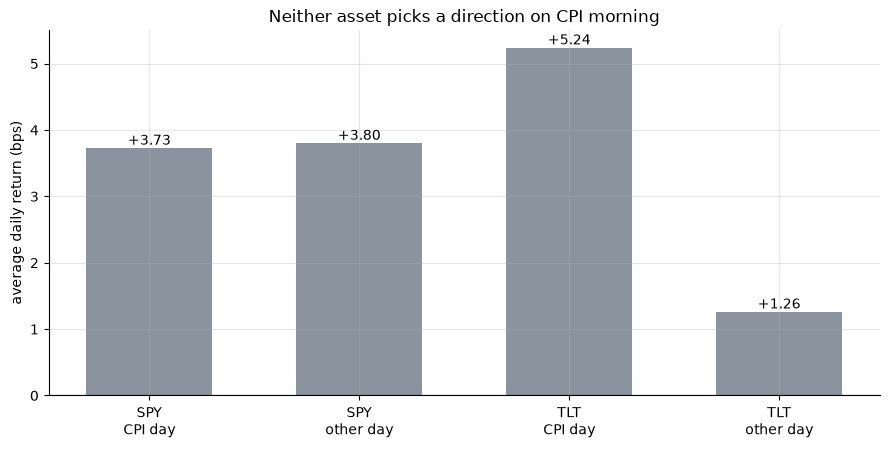

SPY: CPI +3.73 vs other +3.80 bps
TLT: CPI +5.24 vs other +1.26 bps


In [2]:
if HAVE_REAL:
    s_spy = st.cpi_day_stats(SPY); s_tlt = st.cpi_day_stats(TLT)
    vals = [s_spy['cpi_bps'], s_spy['rest_bps'], s_tlt['cpi_bps'], s_tlt['rest_bps']]
else:
    vals = [R['spy_cpi_bps'], R['spy_rest_bps'], R['tlt_cpi_bps'], R['tlt_rest_bps']]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
labels = ['SPY\nCPI day','SPY\nother day','TLT\nCPI day','TLT\nother day']
ax.bar(labels, vals, color=[GREY, GREY, GREY, GREY], width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.2f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average daily return (bps)')
ax.set_title('Neither asset picks a direction on CPI morning')
plt.tight_layout(); plt.show()
print(f'SPY: CPI {vals[0]:+.2f} vs other {vals[1]:+.2f} bps')
print(f'TLT: CPI {vals[2]:+.2f} vs other {vals[3]:+.2f} bps')

CPI-day and other-day returns are practically the same bar for both assets. SPY's gap is Welch *t* = **-0.01** — statistically nothing — and TLT's, despite looking a bit bigger on the page, is *t* = **0.67**, also well under the bar. A random-calendar check confirms it: a random 353-day calendar produces a mean this size or bigger **63% of the time** — there's no direction here to trade.

**Now the loudness question** — this is where it gets interesting:

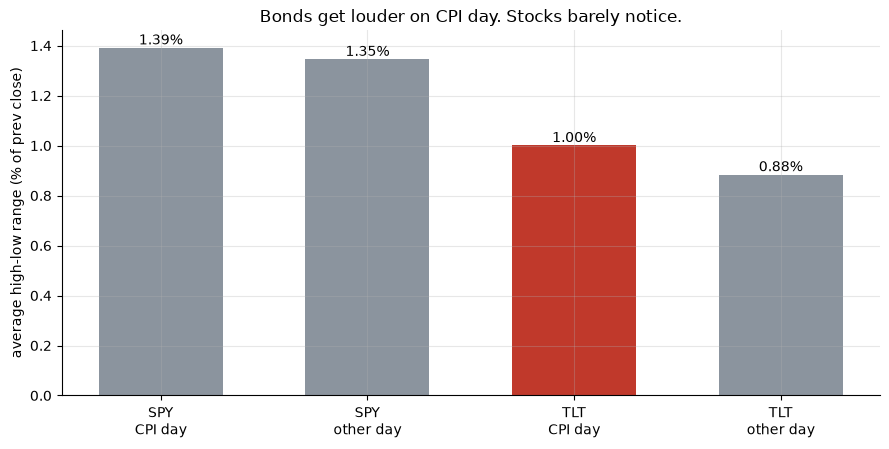

SPY range: CPI 1.392% vs other 1.346%
TLT range: CPI 1.001% vs other 0.884%


In [3]:
if HAVE_REAL:
    rg_spy = st.range_stats(SPY); rg_tlt = st.range_stats(TLT)
    vals = [rg_spy['cpi_range_pct'], rg_spy['rest_range_pct'],
            rg_tlt['cpi_range_pct'], rg_tlt['rest_range_pct']]
else:
    vals = [R['spy_rng_cpi'], R['spy_rng_rest'], R['tlt_rng_cpi'], R['tlt_rng_rest']]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
labels = ['SPY\nCPI day','SPY\nother day','TLT\nCPI day','TLT\nother day']
cols = [GREY, GREY, RED, GREY]
ax.bar(labels, vals, color=cols, width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average high-low range (% of prev close)')
ax.set_title('Bonds get louder on CPI day. Stocks barely notice.')
plt.tight_layout(); plt.show()
print(f'SPY range: CPI {vals[0]:.3f}% vs other {vals[1]:.3f}%')
print(f'TLT range: CPI {vals[2]:.3f}% vs other {vals[3]:.3f}%')

There it is: **TLT's** daily high-low swing jumps from **0.88%** on an ordinary day to **1.00%** on a CPI day — a real, statistically certified effect (Welch *t* = **2.70**, and a random-calendar check finds a random day producing this only **0.03%** of the time). **SPY's** range barely moves (1.35% → 1.39%, *t* = **0.82**, not certifiable). Makes sense: CPI is an inflation number, and inflation is exactly what re-prices the bond market's discount rate. Stocks care too, eventually — just not enough, on the average day, to show up in the statistics.

**And here's the myth we actually set out to test** — "CPI day is the biggest trading day of the month":

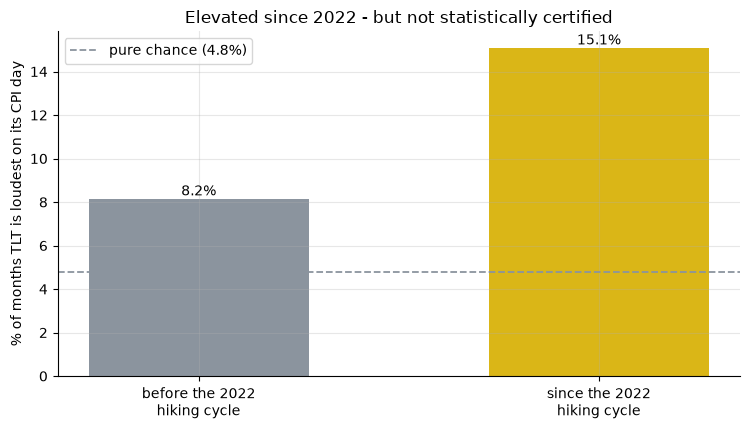

TLT range "biggest day of month" rate: pre 8.2% -> post 15.1%


In [4]:
if HAVE_REAL:
    bd = st.biggest_day_of_month(TLT, TLT_SESSIONS, data.REGIME_SPLIT, metric='range_pct')
    pre, post = bd['pre_rate']*100, bd['post_rate']*100
else:
    pre, post = R['bd_tlt_rng_pre'], R['bd_tlt_rng_post']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['before the 2022\nhiking cycle','since the 2022\nhiking cycle'], [pre, post],
       color=[GREY, AMBER], width=.55)
ax.axhline(R['bd_null'], ls='--', c=GREY, lw=1.3, label=f"pure chance ({R['bd_null']:.1f}%)")
for i,v in enumerate([pre, post]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('% of months TLT is loudest on its CPI day')
ax.set_title('Elevated since 2022 - but not statistically certified')
ax.legend(); plt.tight_layout(); plt.show()
print(f'TLT range "biggest day of month" rate: pre {pre:.1f}% -> post {post:.1f}%')

Even on TLT's realized range — our *strongest* leg of evidence — the "biggest day of the month" rate only rises from **8.2%** of months to **15.1%** since the Fed started hiking. That's a real-looking jump on the page, but the sample of post-2022 months is small, the statistical test of the *difference* falls short of our bar, and even 15% of months is nowhere close to "the biggest day, every month." The catchphrase overstates what the data show.

**Finally — could you actually trade any of this?**

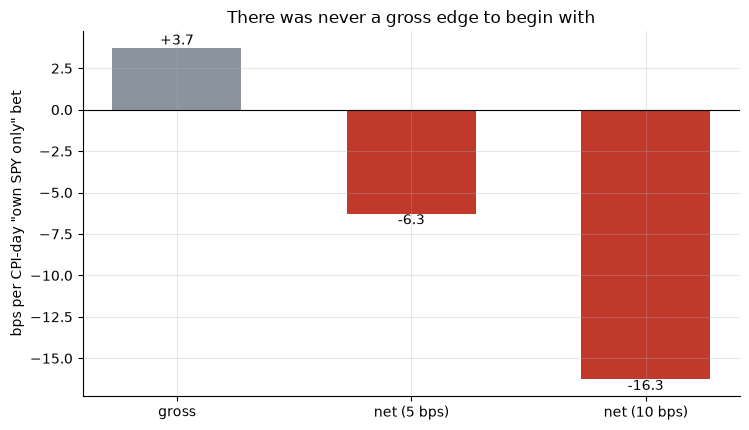

gross +3.73 -> net -6.27 / -16.27 bps


In [5]:
if HAVE_REAL:
    tc5 = st.timer_capture(SPY, cost_bps=5.0)
    tc10 = st.timer_capture(SPY, cost_bps=10.0)
    g, n5, n10 = tc5['gross_bps'], tc5['net_bps'], tc10['net_bps']
else:
    g, n5, n10 = R['tm_gross'], R['tm_net5'], R['tm_net10']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['gross','net (5 bps)','net (10 bps)'], [g, n5, n10],
       color=[GREY, RED, RED], width=.55)
for i,v in enumerate([g, n5, n10]): ax.annotate(f'{v:+.1f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('bps per CPI-day "own SPY only" bet')
ax.set_title('There was never a gross edge to begin with')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f} -> net {n5:+.2f} / {n10:+.2f} bps')

Not really. The "own SPY only on CPI day" timer starts from a gross edge of **+3.73 bps** — practically nothing above the market's own average day — so a normal 5-basis-point round-trip cost flips it to **-6.27 bps net**, a loser. There's no free lunch here: the real effect we found lives in bond *volatility*, not in a direction you can just buy and hold.

## 5 · The verdict

- **Signal — Mixed.** Real for one thing (TLT gets louder on CPI mornings), none for everything else (no direction in stocks or bonds, no loudness bump in stocks).
- **Tradability — Mirage.** No direction to bank, and the one real effect isn't something a simple buy-and-hold position can monetize.
- **"Biggest day of the month"? — Busted.** Directionally plausible since the Fed's 2022 pivot, but the data don't certify it, and even the best case is a small minority of months, not a rule.

## 6 · Going further 🚪

- **The next question is options, not stock.** If bonds really do get louder on CPI day, the honest way to test whether that's *bankable* is a straddle or variance-swap study on TLT/rates around the print — not a directional equity bet.
- **The Fed's own vol crush is a cautionary tale.** Our sibling study [637-fomc-vol-crush](../../637-fomc-vol-crush/) found a real, certified implied-vol collapse on FOMC decision afternoons — and it turned out to be untradable, because futures pre-price the scheduled event. The same skepticism should apply here before anyone gets excited about CPI-day loudness.
- **Sibling studies:** [602-macro-announcement-premium](../../602-macro-announcement-premium/) (the pooled FOMC+CPI+NFP equity premium) and [643-payrolls-day-effect](../../643-payrolls-day-effect/) (the same protocol on Nonfarm Payrolls mornings) — ask related but distinct questions.

*Think CPI-day loudness is bankable through options? Show a net, certifiable edge after the market-maker's spread on release mornings — then we'll talk.*